In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.integrate import quad
import seaborn as sns
from scipy import stats


plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.figsize'] = (10, 6)

# Miary tendencji centralnej i rozproszenia

## Miary tendencji centralnej

### Średnia (mean)
$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

- Suma wszystkich wartości podzielona przez ich liczbę
- Wrażliwa na wartości odstające

### Mediana (median)
- Wartość środkowa posortowanych danych
- Odporna na wartości odstające
- 50. percentyl (Q2)

### Moda (mode)
- Wartość występująca najczęściej w zbiorze danych
- Może być więcej niż jedna moda lub w ogóle nie występować

---

## Miary rozproszenia – klasyczne

### Wariancja (variance)
$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

- Średnia kwadratów odchyleń od średniej
- Jednostka: kwadrat jednostki oryginalnej
- $(n-1)$ = korekta Bessela (dla próby)

### Odchylenie standardowe (standard deviation)
$$s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

- Pierwiastek z wariancji
- **Najczęściej używana miara rozproszenia**
- Ta sama jednostka co dane
- Interpretacja: "typowe odchylenie od średniej"

**Uwaga:** Obie miary są wrażliwe na wartości odstające

---

## Miary rozproszenia – statystyki pozycyjne

Oparte na posortowanych wartościach danych (*order statistics*)

### Rozstęp (range)
Różnica między wartością maksymalną i minimalną
$$\text{Range} = x_{\max} - x_{\min}$$

⚠️ **Problem:** Bardzo wrażliwy na wartości odstające → rzadko użyteczny

### Percentyle i kwantyle

- **Percentyl**: P-ty percentyl to wartość, poniżej której znajduje się co najmniej P% danych
- **Mediana to 50. percentyl**
- Percentyle są w zasadzie tym samym co **kwantyle**, z tą różnicą, że kwantyle indeksuje się ułamkami (np. kwantyl 0.8 to 80. percentyl)

### Rozstęp międzykwartylowy (IQR)
$$\text{IQR} = Q_3 - Q_1$$

gdzie:
- $Q_1$ = pierwszy kwartyl (25. percentyl)
- $Q_3$ = trzeci kwartyl (75. percentyl)

✅ **Zaleta:** Odporny na wartości odstające  
Opisuje rozproszenie środkowych 50% danych

## Eksploracja rozkładu danych

Miary takie jak średnia, mediana, percentyl podsumowuje dane w postaci **jednej liczby**, aby opisać ich położenie lub zmienność.

Równie użyteczne jest jednak **zbadanie ogólnego rozkładu danych**.

---

## Kluczowe pojęcia

**Wykres pudełkowy (Boxplot)**

* Wykres wprowadzony przez Johna Tukeya jako szybki sposób na wizualizację rozkładu danych.

* Jego synonim to *wykres pudełkowy z wąsami* (*box and whiskers plot*).

**Tabela liczebności (Frequency table)**

* Zestawienie liczby wartości numerycznych, które wpadają do określonych przedziałów (koszyków, *bins*).

**Histogram (Histogram)**

* Wykres przedstawiający tabelę liczebności, z przedziałami na osi X i liczebnością (lub proporcją) na osi Y. Choć wizualnie podobny, **histogramu nie należy mylić z wykresem słupkowym**.

**Wykres gęstości (Density plot)**

* Wygładzona wersja histogramu, często tworzona na podstawie **jądrowego estymatora gęstości** (*kernel density estimate*).

In [2]:
# Wczytanie danych
titanic = sns.load_dataset('titanic')
print(titanic.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
titanic["age"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,age
0.05,4.000
0.25,20.125
0.50,28.000
0.75,38.000
0.95,56.000


## Wykres pudełkowy (ang. boxplot)

**Pudełko:**
- Górna krawędź = Q3 (75. percentyl)
- Dolna krawędź = Q1 (25. percentyl)
- Linia w środku = **mediana** (Q2)
- Wysokość pudełka = **IQR** (Interquartile Range = Q3 - Q1)

**Wąsy:**
- Dolny: Q1 - 1.5 × IQR
- Górny: Q3 + 1.5 × IQR
- Pokazują zakres głównej części danych

**Punkty poza wąsami:** wartości odstające (**outliers**)


Text(0, 0.5, 'age')

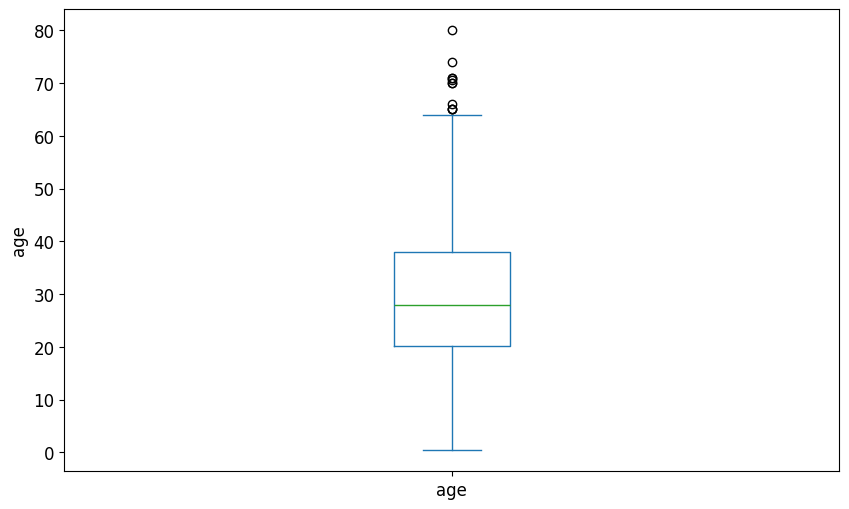

In [4]:
ax = (titanic["age"]).plot.box()
ax.set_ylabel("age")

## Tablice częstości i histogramy

Tablica częstości dzieli zakres zmiennej na równe segmenty i pokazuje liczbę wartości w każdym przedziale.

**Ważne**:

- Uwzględniaj puste przedziały - to użyteczna informacja
- Eksperymentuj z szerokością przedziałów:
    - Zbyt duże → ukrywają ważne cechy rozkładu
    - Zbyt małe → tracisz szerszy obraz



**Różnica między metodami podsumowania**:

- *Percentyle/kwartyle* - równa liczność, różne rozmiary przedziałów
- *Tablice częstości* - równe rozmiary przedziałów, różna liczność

In [6]:
binned_population = pd.cut(titanic["age"], 8)
binned_population.value_counts(sort=False)

,count
age,
"(0.34, 10.368]",64
"(10.368, 20.315]",115
"(20.315, 30.263]",230
"(30.263, 40.21]",155
"(40.21, 50.158]",86
"(50.158, 60.105]",42
"(60.105, 70.052]",17
"(70.052, 80.0]",5


## Histogram

**Histogram** = graficzna reprezentacja tablicy częstości
- Oś X: przedziały (bins)
- Oś Y: liczba obserwacji

**W pandas:**
```python
df.plot.hist(bins=20)  # bins = liczba przedziałów

Text(0, 0.5, 'Wiek')

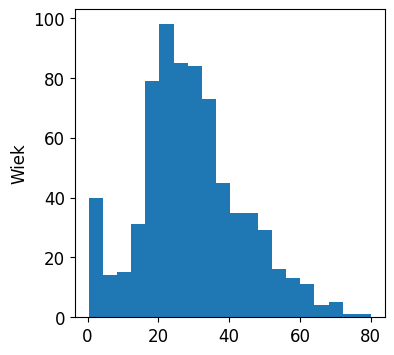

In [7]:
ax = (titanic["age"]).plot.hist(figsize=(4, 4), bins=20)
ax.set_ylabel("Wiek")

## Seaborn

**Seaborn** = biblioteka do wizualizacji danych oparta na Matplotlib
- Wyższy poziom abstrakcji → prostszy kod
- Estetyczne wykresy "out of the box"
- Doskonała integracja z pandas DataFrame
- Automatyczne przetwarzanie danych (np. grupowanie)

---

## Histogram w Seaborn


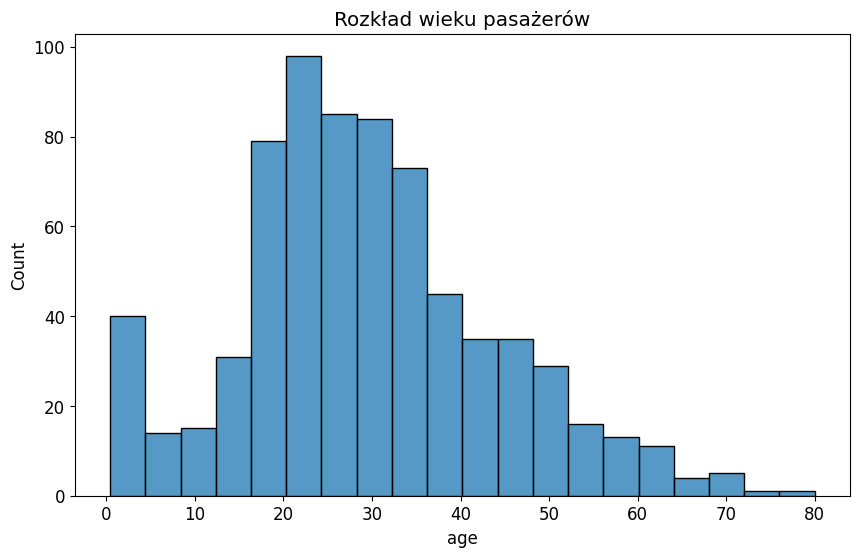

In [12]:
# Histogram dla wieku
sns.histplot(data=titanic, x='age', bins=20)
plt.title('Rozkład wieku pasażerów')
plt.show()

## **Wiele zmiennych**

## Parametr `hue` w Seaborn 🎨

### Co to jest `hue`?

**`hue`** = parametr do **automatycznego grupowania i kolorowania** danych według wartości zmiennej kategorycznej

- Pochodzi z angielskiego "hue" = odcień, barwa
- Automatycznie:
  - Dzieli dane na grupy
  - Przypisuje różne kolory każdej grupie
  - Tworzy legendę
  - Dostosowuje wykres do porównań

---

### Jak działa `hue`?
```python
# BEZ hue - wszystkie dane razem
sns.histplot(data=titanic, x='age')
# Wynik: Jeden histogram ze wszystkimi danymi

# Z hue - automatyczny podział na grupy
sns.histplot(data=titanic, x='age', hue='sex')
# Wynik: Dwa histogramy (male/female) w różnych kolorach

<Axes: xlabel='age', ylabel='Count'>

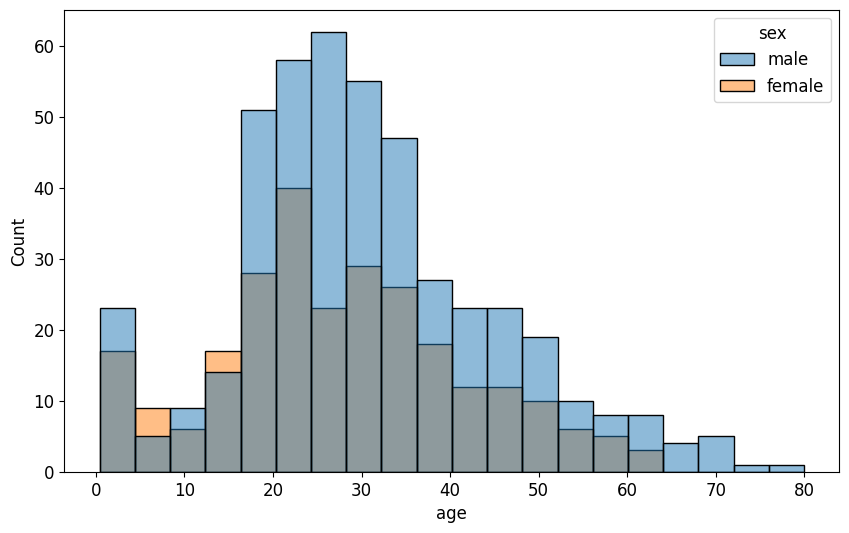

In [13]:
# Z hue - automatyczny podział na grupy
sns.histplot(data=titanic, x="age", hue="sex")

## Boxplot w Seaborn

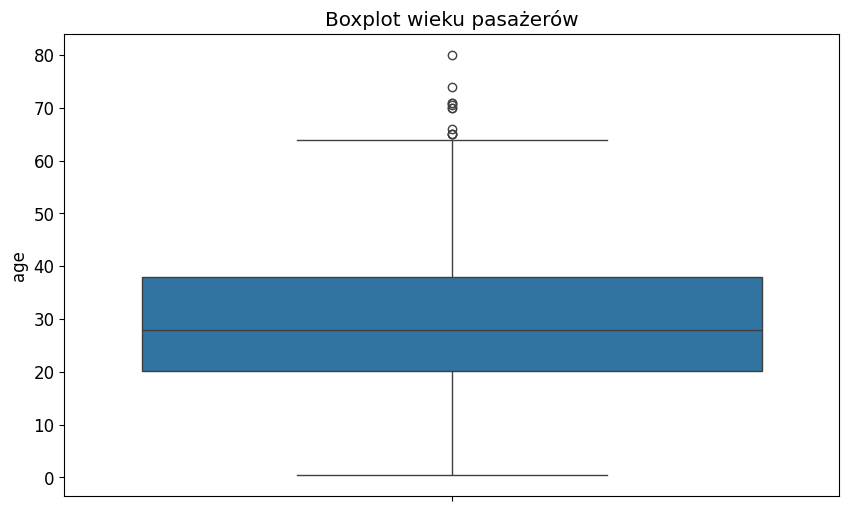

In [14]:
# Prosty boxplot dla wieku
sns.boxplot(data=titanic, y='age')
plt.title('Boxplot wieku pasażerów')
plt.show()

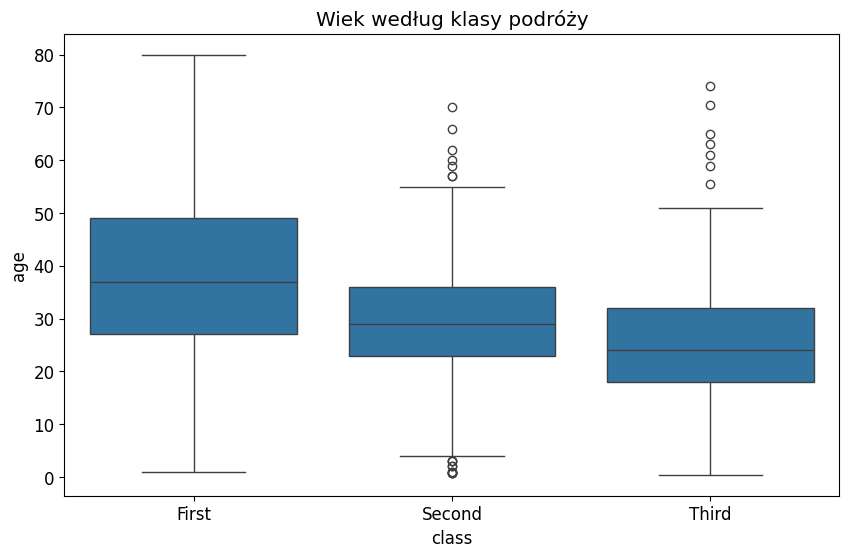

In [15]:
# Porównanie wieku według klasy
sns.boxplot(data=titanic, x='class', y='age')
plt.title('Wiek według klasy podróży')
plt.show()

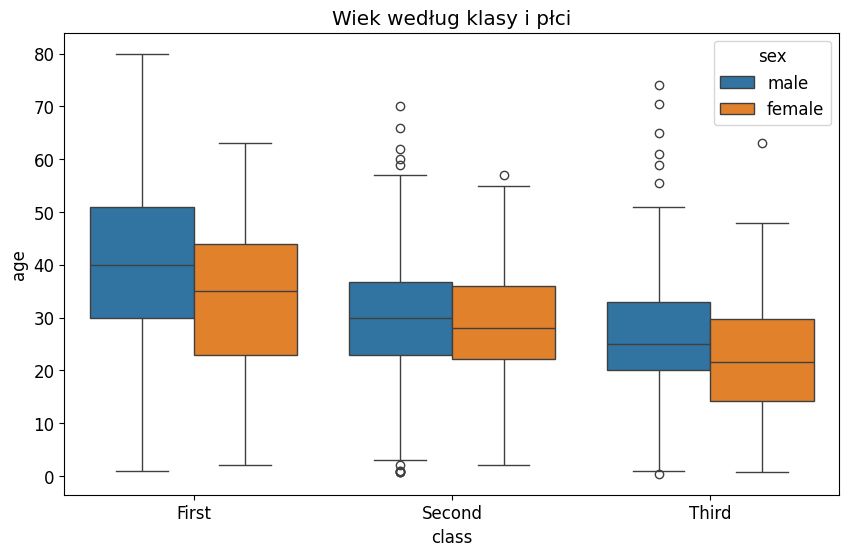

In [16]:
# Z dodatkowym podziałem według płci
sns.boxplot(data=titanic, x='class', y='age', hue='sex')
plt.title('Wiek według klasy i płci')
plt.show()

## **Przewagi Seaborn**

1. **Automatyczne grupowanie** - parametr `hue` automatycznie tworzy podgrupy
2. **Jeden wiersz kodu** zamiast wielu pętli i filtrowania danych
3. **Spójny interfejs** - podobna składnia dla wszystkich wykresów
4. **Ładniejsze wykresy** domyślnie (palety kolorów, style)
5. **Integracja z DataFrame** - nie trzeba wyciągać kolumn ręcznie

# Korelacja między zmiennymi

## Współczynnik korelacji Pearsona

### Definicja
Współczynnik korelacji **r** mierzy **siłę i kierunek liniowej zależności** między dwiema zmiennymi.

### Wzór
$$r = \frac{1}{n-1}\sum_{i=1}^{n} \frac{(x_i - \bar{x})}{s_x} \cdot \frac{(y_i - \bar{y})}{s_y}$$

lub równoważnie:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{(n-1) \cdot s_x \cdot s_y}$$

gdzie:
- $\bar{x}$, $\bar{y}$ = średnie dla zmiennych x i y
- $s_x$, $s_y$ = odchylenia standardowe dla x i y
- $n$ = liczba obserwacji

### Kluczowe właściwości
- **Zakres wartości:** $-1 \leq r \leq 1$
- **Bezwymiarowy** - nie zależy od jednostek pomiarowych
- Standaryzuje zmienne (dzieli przez odchylenia standardowe)

---

## Interpretacja współczynnika korelacji

### Wartości współczynnika r

| Wartość r | Interpretacja |
|-----------|---------------|
| $r = 1$ | Idealna korelacja dodatnia |
| $0.7 < r < 1$ | Silna korelacja dodatnia |
| $0.3 < r < 0.7$ | Umiarkowana korelacja dodatnia |
| $-0.3 < r < 0.3$ | Słaba lub brak korelacji |
| $-0.7 < r < -0.3$ | Umiarkowana korelacja ujemna |
| $-1 < r < -0.7$ | Silna korelacja ujemna |
| $r = -1$ | Idealna korelacja ujemna |

### Kierunek zależności
- **r > 0**: korelacja dodatnia (gdy x rośnie, y rośnie)
- **r < 0**: korelacja ujemna (gdy x rośnie, y maleje)
- **r ≈ 0**: brak zależności liniowej

⚠️ **Ważne:** Współczynnik Pearsona mierzy **tylko zależności liniowe**!

---

## Ograniczenia i macierz korelacji

### Ograniczenia korelacji Pearsona

**Korelacja ≠ Zależność**
- Współczynnik r = 0 nie oznacza braku zależności
- Może istnieć **silna zależność nieliniowa** (np. kwadratowa, wykładnicza)
- Przykład: zależność paraboliczna może mieć r ≈ 0

**Korelacja ≠ Przyczynowość**
- Wysoka korelacja nie oznacza związku przyczynowo-skutkowego
- Może być efektem trzeciej zmiennej (zmienna zakłócająca)

### Macierz korelacji

Dla wielu zmiennych tworzymy **macierz korelacji** - tabelę wszystkich par korelacji:

$$
\mathbf{R} = \begin{bmatrix}
1 & r_{12} & r_{13} & \cdots \\
r_{21} & 1 & r_{23} & \cdots \\
r_{31} & r_{32} & 1 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{bmatrix}
$$

**Właściwości:**
- Symetryczna: $r_{ij} = r_{ji}$
- Diagonal = 1 (korelacja zmiennej ze sobą)
- Wizualizacja: heatmapa (mapa ciepła)

**Zastosowanie:** Szybka analiza zależności między wieloma zmiennymi jednocześnie

## Metoda najmniejszych kwadratów (Least Squares)

### Idea

**Cel:** Znaleźć najlepszą linię prostą $y = ax + b$ do danych

**Jak?** Minimalizując sumę **kwadratów odchyleń** punktów od linii

$$\text{Minimalizuj: } SSE = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = \sum_{i=1}^{n}(y_i - (ax_i + b))^2$$

gdzie:
- $y_i$ = rzeczywista wartość
- $\hat{y}_i = ax_i + b$ = wartość przewidziana przez model
- $(y_i - \hat{y}_i)$ = **residual** (reszta, błąd)

---

### Dlaczego kwadraty?

✅ **Zalety kwadratów:**
- Błędy dodatnie i ujemne się nie znoszą
- Większe kary za duże odchylenia
- Matematycznie wygodne (funkcja różniczkowalna)
- Rozwiązanie analityczne istnieje!

**Wzory na parametry:**
$$a = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$$

$$b = \bar{y} - a\bar{x}$$

slope: 1.88, intercept: 5.13


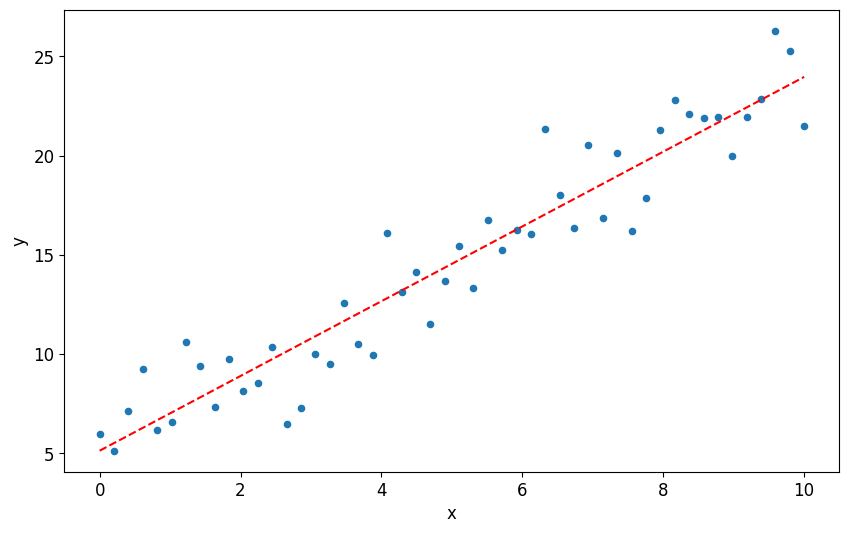

In [ ]:
# Ustawienie seed dla powtarzalności
np.random.seed(42)

# Generowanie danych: y ≈ 2x + 5 + szum
n = 50
x = np.linspace(0, 10, n)
y_true = 2 * x + 5  # prawdziwa zależność
noise = np.random.normal(0, 2, n)  # losowy szum
y = y_true + noise

# Stworzenie DataFrame
data = pd.DataFrame({'x': x, 'y': y})


slope, intercept, r_value, p_value, std_err = stats.linregress(data.x, data.y)
print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
fig, ax = plt.subplots()
data.plot(kind="scatter", x='x', y='y', ax=ax)
y_linreg = slope*x + intercept
ax.plot(x, y_linreg, 'r--')

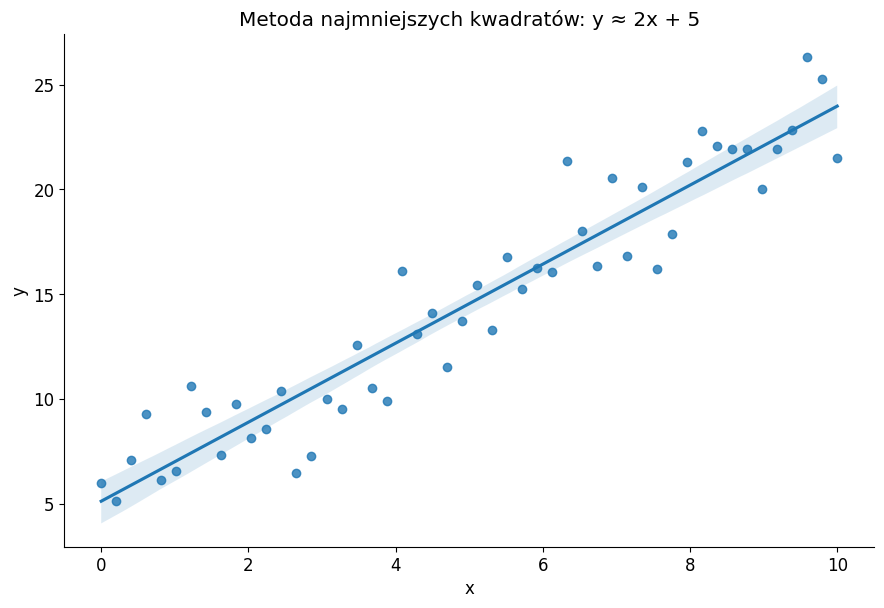

In [18]:
# Ustawienie seed dla powtarzalności
np.random.seed(42)

# Generowanie danych: y ≈ 2x + 5 + szum
n = 50
x = np.linspace(0, 10, n)
y_true = 2 * x + 5  # prawdziwa zależność
noise = np.random.normal(0, 2, n)  # losowy szum
y = y_true + noise

# Stworzenie DataFrame
data = pd.DataFrame({'x': x, 'y': y})

# Wykres z dopasowaniem linii prostej
sns.lmplot(data=data, x='x', y='y', height=6, aspect=1.5)
plt.title('Metoda najmniejszych kwadratów: y ≈ 2x + 5')
plt.show()

## Wykresy macierzowe

* Biblioteka `seaborn` umożliwia szybką analizę eksploracyjną danych uwzględniającą relacje i indywidualne rozkłady za pomocą wykresu macierzowego.
* Wykres taki zawiera histogram ukazujący indywidualny rozkład, a także wykres punktowy prezentujący wspólną zależność cech

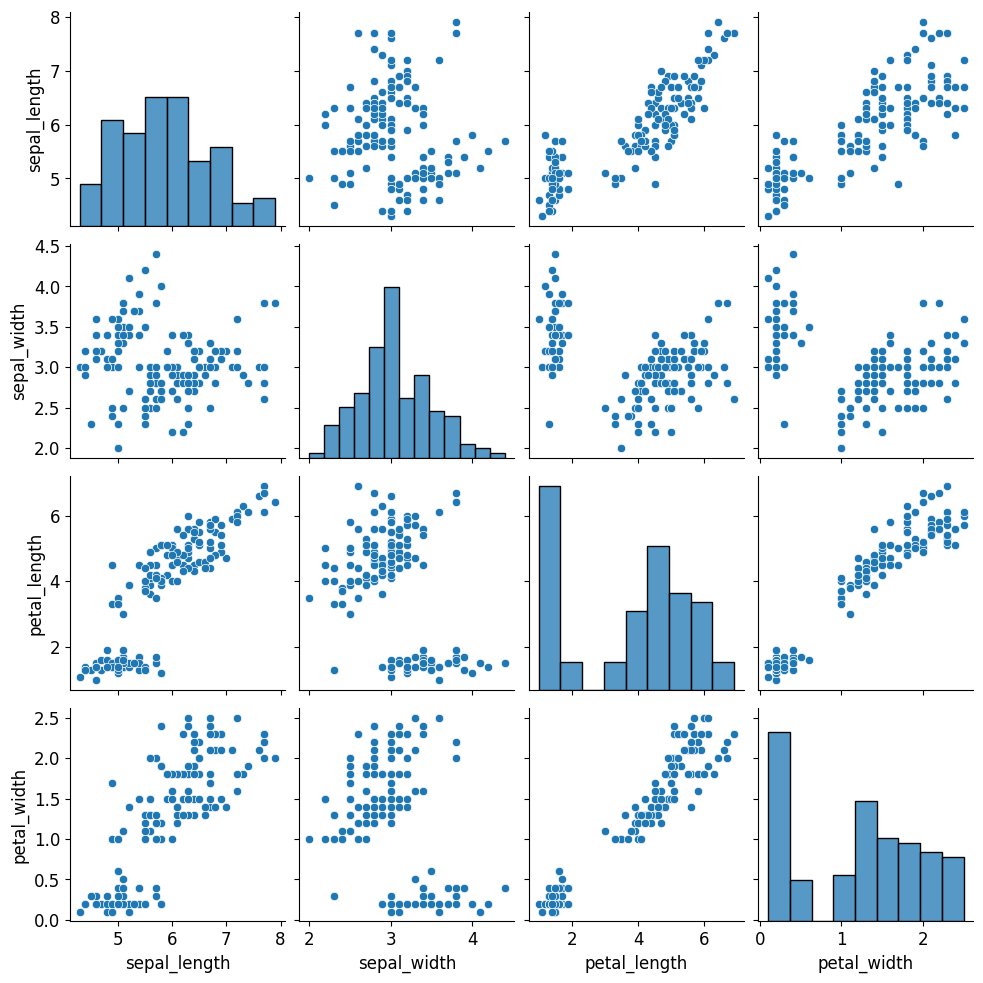

In [ ]:
# Wczytuje zestaw danych Iris za pomocą funkcji load_dataset()
data = sns.load_dataset("iris")
# Tworzy wykres macierzowy
sns.pairplot(data)
# Wyświetla rysunek
plt.show()

## Mapy cieplne
Mapa cieplna stanowi siatkę dwuwymiarową.

* Każda komórka siatki zawiera wartość macierzy.

* Funkcja heatmap() umożliwia także opisywanie każdej komórki:

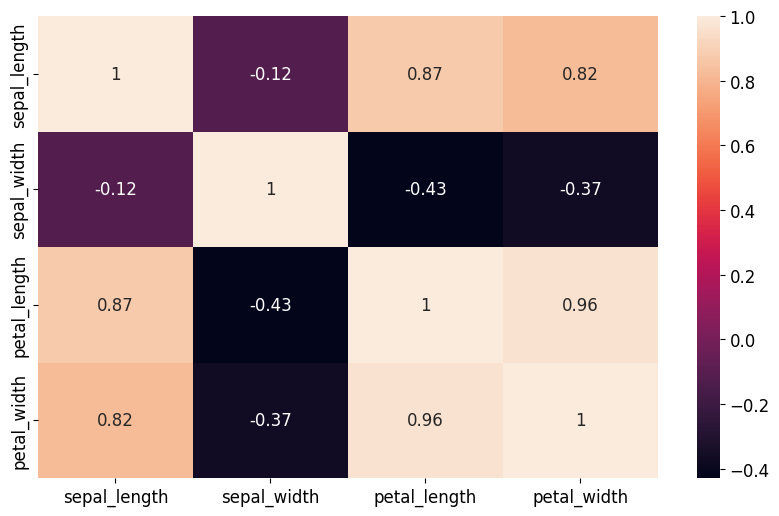

In [17]:
# Wczytuje zestaw danych Iris
data = sns.load_dataset("iris")

# Wybiera tylko kolumny numeryczne do obliczenia korelacji
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Wyszukuje korelację
cor_matrix = numeric_data.corr()

# Tworzy mapę cieplną
sns.heatmap(cor_matrix, annot=True)

# Wyświetla rysunek
plt.show()